# Trabalho Prático 2 - Aprendizagem Automática

**Licenciatura em Engenharia de Sistemas e Tecnologias Informáticas** 

**Unidade Curricular:** Aprendizagem Automática  
**Ano Letivo:** 2025/2026 

---

### Identificação do Grupo
* **Aluno 1:** Bernardo Freitas (79295)
* **Aluno 2:** Afonso Figueiredo (79309)

#### Info
Neste notebook descrevemos, em detalhe e na primeira pessoa, todo o processo que seguimos para treinar e validar um classificador de letras (A–Z) em Língua Gestual Americana (ASL) usando coordenadas de *landmarks* das mãos.

## Objetivos
- Construir um pipeline reprodutível de treino e avaliação.
- Tornar o modelo robusto à posição da mão no enquadramento (invariância a translação e escala).
- Comparar algoritmos pedidos no enunciado: Decision Tree, Random Forest, SVM, KNN e Rede Neuronal.
- Selecionar e afinar o melhor modelo com validação cruzada e *grid search*.
- Guardar os artefactos necessários (modelo, scaler e label encoder) para integração na API (Fase 3).

## Dados
- Ficheiro base: `hand_landmarks_dataset.csv` com 65 colunas (label, hand, 63 coordenadas X/Y/Z de 21 pontos).
- As 63 características são reorganizadas em matriz 21×3 por amostra.

## Coordenadas Relativas ao Pulso
Para remover o viés de posição no ecrã, transformo cada ponto pela regra:
- `p_rel = p_original - p_pulso`
- Normalizo por `max(|p_rel|)` por amostra para reduzir variações de escala.

## Fluxo de Trabalho
1. Carregamento e validação do dataset.
2. Conversão para coordenadas relativas e normalização por amostra.
3. Label encoding das classes (A–Z).
4. Divisão treino/teste estratificada.
5. Standardização das características com `StandardScaler`.
6. Avaliação por validação cruzada dos algoritmos solicitados.
7. Afinação do melhor modelo com *grid search*.
8. Avaliação final (accuracy, relatório de classificação e matriz de confusão).
9. Guardar artefactos para produção (API Flask).

## Reprodutibilidade e Ambiente
- Kernel Python 3.10.11.
- Sementes e configurações fixas onde aplicável para consistência.
- Todos os passos são determinísticos dado o mesmo dataset.


In [2]:
import os
import time
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
DATA_PATH = 'hand_landmarks_dataset.csv'
MODELS_DIR = 'models'
os.makedirs(MODELS_DIR, exist_ok=True)

## 1. Carregamento e Conversão para Coordenadas Relativas

Aqui aplicamos a matemática para corrigir o viés de posição:
$$ P_{novo} = P_{original} - P_{pulso} $$

In [3]:
DATA_PATH = 'hand_landmarks_dataset.csv'
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"O ficheiro {DATA_PATH} não foi encontrado.")
df = pd.read_csv(DATA_PATH)
print(f"Dimensões do ficheiro carregado: {df.shape}")
print(f"Colunas encontradas (primeiras 5): {list(df.columns[:5])}")
y_labels = df.iloc[:, 0].values
X_raw = df.iloc[:, 2:65].values
try:
    X_raw = X_raw.astype(float)
except ValueError:
    print("Aviso: Encontrados valores não numéricos. A limpar...")
    df_temp = pd.DataFrame(X_raw).apply(pd.to_numeric, errors='coerce')
    X_raw = df_temp.fillna(0.0).values
print(f"Dimensões finais de X_raw: {X_raw.shape}")
if X_raw.shape[1] != 63:
    raise ValueError(f"Erro Fatal: X_raw tem {X_raw.shape[1]} colunas. Tem de ter 63 para o reshape(21,3) funcionar!")
X_relative = []
print("A processar coordenadas...")
for row in X_raw:
    landmarks = row.reshape(21, 3)
    wrist = landmarks[0]
    relative_landmarks = landmarks - wrist
    max_val = np.max(np.abs(relative_landmarks))
    if max_val == 0: max_val = 1.0
    relative_landmarks = relative_landmarks / max_val
    X_relative.append(relative_landmarks.flatten())
X = np.array(X_relative)
print("Processamento concluído com sucesso!")


Dimensões do ficheiro carregado: (25566, 65)
Colunas encontradas (primeiras 5): ['label', 'hand', 'x_0', 'y_0', 'z_0']
Dimensões finais de X_raw: (25566, 63)
A processar coordenadas...
Processamento concluído com sucesso!


## 2. Pré-processamento Final (Encoding, Split, Scaling)

In [4]:
le = LabelEncoder()
y = le.fit_transform(y_labels)
print(f"Classes detetadas: {le.classes_}")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
print(f"Dados de Treino prontos: {X_train_s.shape}")

Classes detetadas: ['A' 'B' 'C' 'D' 'E' 'F' 'G' 'H' 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R'
 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z']
Dados de Treino prontos: (20452, 63)


## 3. Comparação de Modelos

In [5]:
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'Neural Network': MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=500, random_state=42)
}

print("A avaliar modelos...")
results_data = []

for name, model in models.items():
    cv_results = cross_validate(model, X_train_s, y_train, cv=5, scoring='accuracy', n_jobs=-1)
    mean_acc = cv_results['test_score'].mean()
    
    results_data.append({'Model': name, 'Accuracy': mean_acc})
    print(f"-> {name}: Acc = {mean_acc:.4f}")

df_results = pd.DataFrame(results_data).sort_values(by='Accuracy', ascending=False)
display(df_results)

A avaliar modelos...
-> Decision Tree: Acc = 0.9987
-> Random Forest: Acc = 0.9999
-> SVM: Acc = 0.9996
-> KNN: Acc = 0.9999
-> Neural Network: Acc = 0.9999


,Model,Accuracy
3,KNN,0.999902
1,Random Forest,0.999853
4,Neural Network,0.999853
2,SVM,0.999609
0,Decision Tree,0.998680


## 4. Otimização e Treino Final
Vamos focar no melhor modelo (neural_networks).

In [6]:
from sklearn.neural_network import MLPClassifier
print("A treinar modelo final (Neural Network)...")
model = MLPClassifier(random_state=42, max_iter=1000)
param_grid = {
    'hidden_layer_sizes': [(128, 64), (256, 128, 64)],
    'alpha': [0.0001, 0.001],
    'learning_rate_init': [0.001]
}
grid = GridSearchCV(model, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid.fit(X_train_s, y_train)
final_model = grid.best_estimator_
print(f"Melhores parâmetros: {grid.best_params_}")
print(f"Melhor Score de Validação: {grid.best_score_:.4f}")
acc = final_model.score(X_test_s, y_test)
print(f"Precisão no Teste: {acc:.4f}")

A treinar modelo final (Neural Network)...
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Melhores parâmetros: {'alpha': 0.0001, 'hidden_layer_sizes': (256, 128, 64), 'learning_rate_init': 0.001}
Melhor Score de Validação: 1.0000
Precisão no Teste: 1.0000


## 5. Avaliação Final e Matriz de Confusão

Relatório Final:
              precision    recall  f1-score   support

           A       1.00      1.00      1.00       200
           B       1.00      1.00      1.00       200
           C       1.00      1.00      1.00       189
           D       1.00      1.00      1.00       200
           E       1.00      1.00      1.00       200
           F       1.00      1.00      1.00       200
           G       1.00      1.00      1.00       200
           H       1.00      1.00      1.00       200
           I       1.00      1.00      1.00       200
           J       1.00      1.00      1.00       200
           K       1.00      1.00      1.00       200
           L       1.00      1.00      1.00       200
           M       1.00      1.00      1.00       188
           N       1.00      1.00      1.00       200
           O       1.00      1.00      1.00       137
           P       1.00      1.00      1.00       200
           Q       1.00      1.00      1.00       200
          

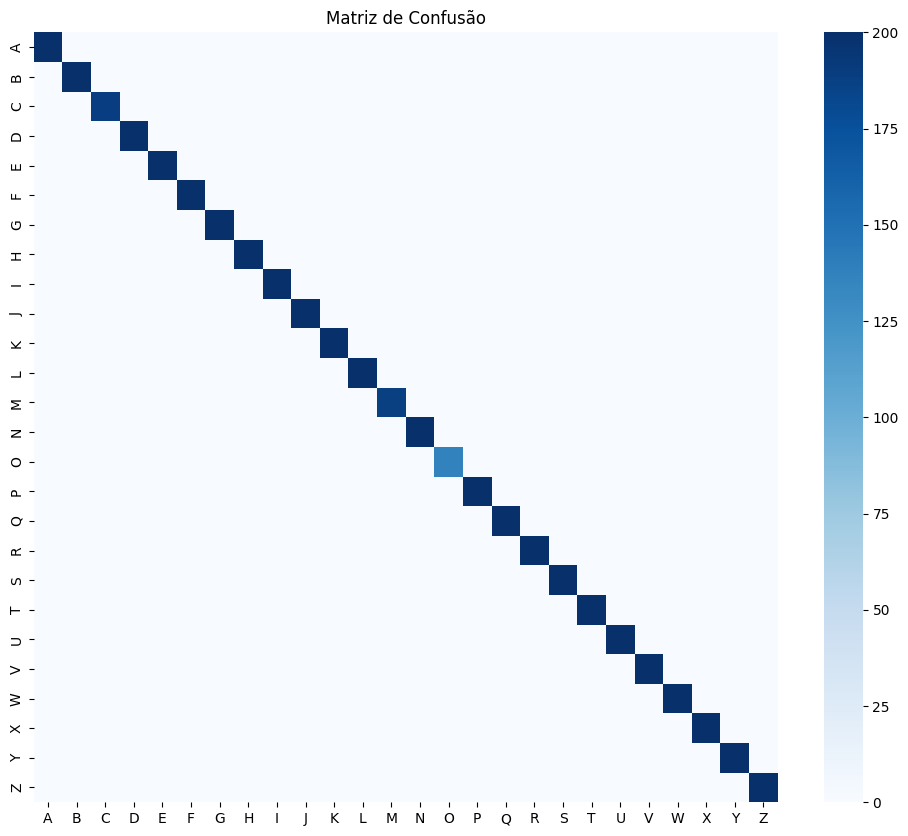

In [7]:
y_pred = final_model.predict(X_test_s)

print("Relatório Final:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de Confusão')
plt.show()

## 6. Guardar Artefactos
Estes ficheiros serão carregados pelo `app.py`.

In [8]:
print("A guardar modelos...")
joblib.dump(final_model, os.path.join(MODELS_DIR, 'best_model.pkl'))
joblib.dump(scaler, os.path.join(MODELS_DIR, 'scaler_hand_sign.pkl'))
joblib.dump(le, os.path.join(MODELS_DIR, 'label_encoder.pkl'))
print("Tudo guardado em 'models/'. Reinicie a API Flask agora!")

A guardar modelos...
Tudo guardado em 'models/'. Reinicie a API Flask agora!
